In [5]:
import pandas as pd
import numpy as np
import pandas_gbq
from google.oauth2 import service_account
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns

# Input Data

In [6]:
coorporate_clients = pd.read_csv('/Users/dzakwan.muhammad/My Drive/Personal Project/Bootcamp/Purwadhika/capstone/module_2/16. Blue Bird/bb_corporate_clients.csv')
coorporate_clients

,company_id,company_name,industry
0,CORP-0001,PT. Korporat Sukses 0 Tbk,Mining
1,CORP-0002,PT. Korporat Sukses 1 Tbk,Consulting
2,CORP-0003,PT. Korporat Sukses 2 Tbk,Banking
3,CORP-0004,PT. Korporat Sukses 3 Tbk,Banking
4,CORP-0005,PT. Korporat Sukses 4 Tbk,Media
...,...,...,...
495,CORP-0496,PT. Korporat Sukses 495 Tbk,Media
496,CORP-0497,PT. Korporat Sukses 496 Tbk,Consulting
497,CORP-0498,PT. Korporat Sukses 497 Tbk,Media
498,CORP-0499,PT. Korporat Sukses 498 Tbk,Media


In [7]:
drivers = pd.read_csv('/Users/dzakwan.muhammad/My Drive/Personal Project/Bootcamp/Purwadhika/capstone/module_2/16. Blue Bird/bb_drivers.csv')
drivers

,driver_id,pool_location,driver_rating
0,DRV-BB-00001,Pool Kelapa Gading,4.93
1,DRV-BB-00002,Pool Puri,4.80
2,DRV-BB-00003,Pool Puri,4.72
3,DRV-BB-00004,Pool Ciputat,4.76
4,DRV-BB-00005,Pool Ciputat,4.87
...,...,...,...
11995,DRV-BB-11996,Pool Kramat Jati,4.71
11996,DRV-BB-11997,Pool Kramat Jati,4.67
11997,DRV-BB-11998,Pool Halim,4.83
11998,DRV-BB-11999,Pool Halim,4.98


In [8]:
trips = pd.read_csv('/Users/dzakwan.muhammad/My Drive/Personal Project/Bootcamp/Purwadhika/capstone/module_2/16. Blue Bird/bb_trips.csv')
trips 

,trip_id,driver_id,company_id,service_type,booking_time,meter_start_time,dropoff_time,distance_km,payment_method,total_fare
0,TRP000000001,DRV-BB-02795,NaN,blue bird,2023-12-01 07:42:00,2023-12-01 07:45:00,2023-12-01 10:58:00,39.1,MyBluebird App,202000.0
1,TRP000000002,DRV-BB-08300,NaN,Bluebird,2023-11-30 10:10:00,2023-11-30 10:15:00,2023-11-30 11:19:00,17.3,MyBluebird App,93000.0
2,TRP000000003,DRV-BB-10491,NaN,Bluebird,2024-03-21 20:01:00,2024-03-21 20:09:00,2024-03-21 22:01:00,25.5,Credit Card,134000.0
3,TRP000000004,DRV-BB-10363,NaN,blue bird,2024-03-13 18:09:00,2024-03-13 18:15:00,2024-03-13 19:08:00,15.0,MyBluebird App,81500.0
4,TRP000000005,DRV-BB-09244,NaN,silver,2024-03-03 15:46:00,2024-03-03 15:55:00,2024-03-03 17:17:00,29.3,Cash,153000.0
...,...,...,...,...,...,...,...,...,...,...
299995,TRP000299996,DRV-BB-00794,NaN,Bluebird,2023-10-30 16:12:00,2023-10-30 16:15:00,2023-10-30 18:17:00,36.4,MyBluebird App,188500.0
299996,TRP000299997,DRV-BB-03459,NaN,silver,2023-12-16 22:00:00,2023-12-16 22:07:00,2023-12-16 22:21:00,4.1,eVoucher Corporate,27000.0
299997,TRP000299998,DRV-BB-06309,NaN,silver,2023-11-15 13:55:00,2023-11-15 14:03:00,2023-11-15 16:47:00,36.3,Cash,188000.0
299998,TRP000299999,DRV-BB-07345,NaN,Bluebird,2023-12-20 20:25:00,2023-12-20 20:27:00,2023-12-20 23:11:00,40.0,MyBluebird App,206500.0


# Data Cleaning

## Function

In [9]:
def explore_data(df):
    for i in df.columns:
        print('column:', i, '| data type:', df[i].dtypes)
        display(df[[i]].drop_duplicates().sort_values(by=i))
        print('=='*50)
        print()

In [10]:
def cleaning_data(df):
    # 1 - convert to datetime data type
    for i in df.columns:
        if 'time' in str(i).lower():
            df[i] = pd.to_datetime(df[i])
            df[i] = df[i].dt.tz_localize('Asia/Jakarta') 
    print('1 - incorrect data type has been resolved')

    # 2 - handle  inconsistent value in service_type
    df['service_type_clean'] = df['service_type'].case_when([
        (df['service_type'].str.contains('blue', case=False), 'Bluebird'),
        (df['service_type'].str.contains('bb ', case=False), 'Bluebird'),
        (df['service_type'].str.contains('silver', case=False), 'Silverbird'),

    ])
    print('2 - inconsistent value has been resolved')

    # 3 - repair the anomaly value
    df['trip_time_s'] = (df['dropoff_time'] - df['meter_start_time']).dt.total_seconds().astype('int64')
    df['distance_m_per_second'] = round((df['distance_km']*1000)/df['trip_time_s'], 4)
    df['fare_per_distance_km'] = round((df['total_fare'])/df['distance_km'], 4)

    df_removeoutlier = df[(df['distance_km']>1) & (df['distance_km']<9999)]

    distance_second_df = df_removeoutlier[['distance_m_per_second']].describe()
    fare_distance_df = df_removeoutlier[['fare_per_distance_km']].describe()

    # 3.1 repair anomaly in 'distance_km' column
    df['distance_km_clean'] = df['distance_km'].case_when([
        (
            (df['distance_km'] < 1) | (df['distance_km'] >= 9999),
            round((distance_second_df.loc['50%'].values[0] * df['trip_time_s']) / 1000, 1)
        )
    ])

    # 3.2 repair anomaly in 'total_fare' column
    df['total_fare_clean'] = df['total_fare'].case_when([
        (
            df['total_fare']>=1500000,
            round((fare_distance_df.loc['50%'].values[0] * df['distance_km_clean']), 1)
        )
    ])

    # 3.3 finalization
    df = df.drop(columns=['trip_time_s', 'distance_m_per_second', 'fare_per_distance_km', 'service_type', 'distance_km', 'total_fare']).rename(columns={'distance_km_clean': 'distance_km', 'total_fare_clean': 'total_fare', 'service_type_clean': 'service_type'})

    print('3 - anomaly value has been resolved')
    return df

In [11]:
def checking_validation_result(df):
    for i in df.columns:
        if i == 'service_type':
            print('column:', i, '| data type:', df[i].dtypes)
            display(df[[i]].drop_duplicates().sort_values(by=i))
            print('=='*50)
            print()
        elif i in (['distance_km', 'total_fare']):
            print('column:', i, '| data type:', df[i].dtypes)
            display(df[[i]].describe())
            print('=='*50)

## Data Exploration

### coorporate clients

In [12]:
coorporate_clients.describe()

,company_id,company_name,industry
count,500,500,500
unique,500,500,6
top,CORP-0001,PT. Korporat Sukses 0 Tbk,Consulting
freq,1,1,89


In [13]:
coorporate_clients.isna().sum()

company_id      0
company_name    0
industry        0
dtype: int64

In [14]:
explore_data(coorporate_clients)

column: company_id | data type: str


,company_id
0,CORP-0001
1,CORP-0002
2,CORP-0003
3,CORP-0004
4,CORP-0005
...,...
495,CORP-0496
496,CORP-0497
497,CORP-0498
498,CORP-0499



column: company_name | data type: str


,company_name
0,PT. Korporat Sukses 0 Tbk
1,PT. Korporat Sukses 1 Tbk
10,PT. Korporat Sukses 10 Tbk
100,PT. Korporat Sukses 100 Tbk
101,PT. Korporat Sukses 101 Tbk
...,...
95,PT. Korporat Sukses 95 Tbk
96,PT. Korporat Sukses 96 Tbk
97,PT. Korporat Sukses 97 Tbk
98,PT. Korporat Sukses 98 Tbk



column: industry | data type: str


,industry
2,Banking
1,Consulting
11,FMCG
4,Media
0,Mining
19,Tech StartUp


### drivers

In [15]:
drivers.describe()

,driver_rating
count,12000.000000
mean,4.799426
std,0.114732
min,4.600000
25%,4.700000
50%,4.800000
75%,4.900000
max,5.000000


In [12]:
drivers.isna().sum()

driver_id        0
pool_location    0
driver_rating    0
dtype: int64

In [16]:
explore_data(drivers)

column: driver_id | data type: str


,driver_id
0,DRV-BB-00001
1,DRV-BB-00002
2,DRV-BB-00003
3,DRV-BB-00004
4,DRV-BB-00005
...,...
11995,DRV-BB-11996
11996,DRV-BB-11997
11997,DRV-BB-11998
11998,DRV-BB-11999



column: pool_location | data type: str


,pool_location
5,Pool BSD
3,Pool Ciputat
24,Pool Halim
0,Pool Kelapa Gading
10,Pool Kramat Jati
9,Pool Mampang
1,Pool Puri



column: driver_rating | data type: float64


,driver_rating
20,4.60
9,4.61
40,4.62
16,4.63
29,4.64
5,4.65
13,4.66
34,4.67
18,4.68
47,4.69


### trips

In [17]:
trips.describe()

,distance_km,total_fare
count,300000.000000,3.000000e+05
mean,58.026657,1.318710e+05
std,587.591046,1.157914e+05
min,-5.000000,1.650000e+04
25%,12.500000,7.050000e+04
50%,23.400000,1.250000e+05
75%,34.300000,1.795000e+05
max,9999.000000,1.500000e+06


anomaly detected on `distance_km` and `total_fare` column based on `std` variable

In [18]:
trips.isna().sum()

trip_id                  0
driver_id                0
company_id          248723
service_type             0
booking_time             0
meter_start_time         0
dropoff_time             0
distance_km              0
payment_method           0
total_fare               0
dtype: int64

`null` value exists but it is not anomaly

In [19]:
explore_data(trips)

column: trip_id | data type: str


,trip_id
0,TRP000000001
1,TRP000000002
2,TRP000000003
3,TRP000000004
4,TRP000000005
...,...
299995,TRP000299996
299996,TRP000299997
299997,TRP000299998
299998,TRP000299999



column: driver_id | data type: str


,driver_id
24633,DRV-BB-00001
1219,DRV-BB-00002
18208,DRV-BB-00003
1006,DRV-BB-00004
2134,DRV-BB-00005
...,...
6973,DRV-BB-11996
10124,DRV-BB-11997
8643,DRV-BB-11998
5354,DRV-BB-11999



column: company_id | data type: str


...

,distance_km
1069,-5.0
8,0.1
138,2.0
135,2.1
51,2.2
...,...
371,44.7
488,44.8
331,44.9
1281,45.0



column: payment_method | data type: str


,payment_method
4,Cash
2,Credit Card
0,MyBluebird App
8,eVoucher Corporate



column: total_fare | data type: float64


,total_fare
138,16500.0
135,17000.0
51,17500.0
389,18000.0
553,18500.0
...,...
488,230500.0
331,231000.0
1281,231500.0
239,350000.0


multiple anomalies detected based on the exploration:
- inconsistent `service_type` value
- incorrect data type for `booking_time`, `meter_start_time`, `dropoff_time`

## Data Repairation

In [20]:
trips = cleaning_data(trips)
trips

1 - incorrect data type has been resolved
2 - inconsistent value has been resolved
3 - anomaly value has been resolved


,trip_id,driver_id,company_id,booking_time,meter_start_time,dropoff_time,payment_method,service_type,distance_km,total_fare
0,TRP000000001,DRV-BB-02795,NaN,2023-12-01 07:42:00+07:00,2023-12-01 07:45:00+07:00,2023-12-01 10:58:00+07:00,MyBluebird App,Bluebird,39.1,202000.0
1,TRP000000002,DRV-BB-08300,NaN,2023-11-30 10:10:00+07:00,2023-11-30 10:15:00+07:00,2023-11-30 11:19:00+07:00,MyBluebird App,Bluebird,17.3,93000.0
2,TRP000000003,DRV-BB-10491,NaN,2024-03-21 20:01:00+07:00,2024-03-21 20:09:00+07:00,2024-03-21 22:01:00+07:00,Credit Card,Bluebird,25.5,134000.0
3,TRP000000004,DRV-BB-10363,NaN,2024-03-13 18:09:00+07:00,2024-03-13 18:15:00+07:00,2024-03-13 19:08:00+07:00,MyBluebird App,Bluebird,15.0,81500.0
4,TRP000000005,DRV-BB-09244,NaN,2024-03-03 15:46:00+07:00,2024-03-03 15:55:00+07:00,2024-03-03 17:17:00+07:00,Cash,Silverbird,29.3,153000.0
...,...,...,...,...,...,...,...,...,...,...
299995,TRP000299996,DRV-BB-00794,NaN,2023-10-30 16:12:00+07:00,2023-10-30 16:15:00+07:00,2023-10-30 18:17:00+07:00,MyBluebird App,Bluebird,36.4,188500.0
299996,TRP000299997,DRV-BB-03459,NaN,2023-12-16 22:00:00+07:00,2023-12-16 22:07:00+07:00,2023-12-16 22:21:00+07:00,eVoucher Corporate,Silverbird,4.1,27000.0
299997,TRP000299998,DRV-BB-06309,NaN,2023-11-15 13:55:00+07:00,2023-11-15 14:03:00+07:00,2023-11-15 16:47:00+07:00,Cash,Silverbird,36.3,188000.0
299998,TRP000299999,DRV-BB-07345,NaN,2023-12-20 20:25:00+07:00,2023-12-20 20:27:00+07:00,2023-12-20 23:11:00+07:00,MyBluebird App,Bluebird,40.0,206500.0


In [21]:
checking_validation_result(trips)

column: service_type | data type: str


,service_type
0,Bluebird
32,E-Cabbie
9,Goldenbird
4,Silverbird



column: distance_km | data type: float64


,distance_km
count,300000.000000
mean,23.478004
std,12.435431
min,1.300000
25%,12.700000
50%,23.400000
75%,34.300000
max,64.800000


column: total_fare | data type: float64


,total_fare
count,300000.000000
mean,125048.061944
std,64044.821940
min,8444.400000
25%,70000.000000
50%,124000.000000
75%,178500.000000
max,350000.000000


In [22]:
explore_data(trips)

column: trip_id | data type: str


,trip_id
0,TRP000000001
1,TRP000000002
2,TRP000000003
3,TRP000000004
4,TRP000000005
...,...
299995,TRP000299996
299996,TRP000299997
299997,TRP000299998
299998,TRP000299999



column: driver_id | data type: str


,driver_id
24633,DRV-BB-00001
1219,DRV-BB-00002
18208,DRV-BB-00003
1006,DRV-BB-00004
2134,DRV-BB-00005
...,...
6973,DRV-BB-11996
10124,DRV-BB-11997
8643,DRV-BB-11998
5354,DRV-BB-11999



column: company_id | data type: str


...

,service_type
0,Bluebird
32,E-Cabbie
9,Goldenbird
4,Silverbird



column: distance_km | data type: float64


,distance_km
130899,1.3
14992,1.6
16040,1.9
138,2.0
135,2.1
...,...
29003,58.7
17452,59.2
97555,59.5
13839,63.8



column: total_fare | data type: float64


,total_fare
161751,8444.4
57205,10027.8
28264,11083.3
60801,12666.7
32377,14250.0
...,...
138623,305583.3
17452,312444.4
97555,314027.8
13839,336722.2


In [23]:
trips.describe()

,distance_km,total_fare
count,300000.000000,300000.000000
mean,23.478004,125048.061944
std,12.435431,64044.821940
min,1.300000,8444.400000
25%,12.700000,70000.000000
50%,23.400000,124000.000000
75%,34.300000,178500.000000
max,64.800000,350000.000000


# Upload Data To Google Big Query

## Configuration

In [2]:
key_path = '/Users/dzakwan.muhammad/My Drive/Personal Project/Bootcamp/Purwadhika/notebook/module_2/purwadhika-498212-86204692ac79.json'

scopes = ["https://www.googleapis.com/auth/bigquery"]
credentials = service_account.Credentials.from_service_account_file(
    key_path,
    scopes=scopes
)

project_id = 'purwadhika-498212'
dataset_id = 'bluebird_capstone' 

client = bigquery.Client(project=project_id, credentials=credentials)

job_config = bigquery.LoadJobConfig(
    write_disposition='WRITE_APPEND'
)

## Write Table

In [20]:
table_id = f"{project_id}.{dataset_id}.coorporate_clients"

create_table_sql = f"""
CREATE TABLE `{table_id}` (
    company_id      STRING,
    company_name    STRING,
    industry        STRING

)
"""
client.query(create_table_sql)

write_table = client.load_table_from_dataframe(
    dataframe = coorporate_clients,
    destination = table_id,
    job_config = job_config
)

write_table.result()

LoadJob<project=purwadhika-498212, location=asia-southeast2, id=b09fbc67-4b7d-48a9-8435-40c754a6c157>

In [21]:
table_id = f"{project_id}.{dataset_id}.drivers"

create_table_sql = f"""
CREATE TABLE `{table_id}` (
    driver_id           STRING,
    pool_location       STRING,
    driver_rating       FLOAT64
)
"""
client.query(create_table_sql)

write_table = client.load_table_from_dataframe(
    dataframe = drivers,
    destination = table_id,
    job_config = job_config
)

write_table.result()

LoadJob<project=purwadhika-498212, location=asia-southeast2, id=d9b8937a-a9d6-46b3-924b-c19fa1486628>

In [23]:
table_id = f"{project_id}.{dataset_id}.trips"

create_table_sql = f"""
CREATE TABLE `{table_id}` (
    trip_id             STRING,
    driver_id           STRING,
    company_id          STRING,
    booking_time        TIMESTAMP,
    meter_start_time    TIMESTAMP,
    dropoff_time        TIMESTAMP,
    payment_method      STRING,
    service_type        STRING,
    distance_km         FLOAT64,
    total_fare          FLOAT64
)
"""
client.query(create_table_sql)

write_table = client.load_table_from_dataframe(
    dataframe = trips,
    destination = table_id,
    job_config = job_config
)

write_table.result()

LoadJob<project=purwadhika-498212, location=asia-southeast2, id=b30ec666-3ec9-40d5-8082-fd6886802700>

# Data Analysis

In [25]:
query = """
CREATE OR REPLACE TABLE purwadhika-498212.bluebird_capstone.trips_details AS
SELECT
  a.*,
  IF(a.meter_start_time < a.booking_time, TRUE, FALSE) AS is_driver_cheated,
  b.company_name,
  b.industry AS company_industry,
  c.pool_location AS driver_pool_location,
  c.driver_rating
FROM
  purwadhika-498212.bluebird_capstone.trips AS a
FULL OUTER JOIN
  purwadhika-498212.bluebird_capstone.coorporate_clients AS b
ON
  a.company_id = b.company_id
FULL OUTER JOIN
  purwadhika-498212.bluebird_capstone.drivers AS c
ON
  a.driver_id = c.driver_id
;
"""

job = client.query(query)
job.result()

In [53]:
query = """
SELECT
    is_driver_cheated,
    COUNT(DISTINCT trip_id) AS total,
    COUNT(DISTINCT trip_id) / SUM(COUNT(DISTINCT trip_id)) OVER() * 100 AS percentage
FROM
    purwadhika-498212.bluebird_capstone.trips_details
GROUP BY
    1
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,is_driver_cheated,total,percentage
0,False,291000,97.0
1,True,9000,3.0


In [55]:
query = """
SELECT
    service_type,
    COUNT(DISTINCT trip_id) AS total,
    ROUND(COUNT(DISTINCT trip_id) / SUM(COUNT(DISTINCT trip_id)) OVER() * 100, 2) AS percentage
FROM
    purwadhika-498212.bluebird_capstone.trips_details
WHERE
    is_driver_cheated = TRUE
GROUP BY
    1
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,service_type,total,percentage
0,Bluebird,6319,70.21
1,Silverbird,1788,19.87
2,Goldenbird,467,5.19
3,E-Cabbie,426,4.73


In [57]:
query = """
SELECT
    driver_pool_location,
    COUNT(DISTINCT trip_id) AS total,
    ROUND(COUNT(DISTINCT trip_id) / SUM(COUNT(DISTINCT trip_id)) OVER() * 100, 2) AS percentage
FROM
    purwadhika-498212.bluebird_capstone.trips_details
WHERE
    is_driver_cheated = TRUE
GROUP BY
    1
ORDER BY
    1 ASC
;
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,driver_pool_location,total,percentage
0,Pool BSD,1323,14.70
1,Pool Ciputat,1338,14.87
2,Pool Halim,1287,14.30
3,Pool Kelapa Gading,1239,13.77
4,Pool Kramat Jati,1303,14.48
5,Pool Mampang,1230,13.67
6,Pool Puri,1280,14.22


In [28]:
query = """
CREATE OR REPLACE TABLE purwadhika-498212.bluebird_capstone.driver_cheated_trips_details AS
SELECT
	driver_id,
    driver_pool_location,
    driver_rating,
	COUNT(DISTINCT trip_id) AS total_completed_trips,
	SUM(CASE WHEN is_driver_cheated = TRUE THEN 1 ELSE 0 END) AS total_cheated_trips,
	ROUND((SUM(CASE WHEN is_driver_cheated = TRUE THEN 1 ELSE 0 END) / COUNT(DISTINCT trip_id)) * 100, 2) AS cheated_trips_percentage
FROM
	purwadhika-498212.bluebird_capstone.trips_details
GROUP BY
	ALL
ORDER BY
	6 DESC
;
"""

job = client.query(query)
job.result()

In [61]:
query = """
SELECT
    *
FROM
    purwadhika-498212.bluebird_capstone.driver_cheated_trips_details
ORDER BY
    total_cheated_trips DESC
;
"""

cheated_driver_df = client.query(query).to_dataframe()
cheated_driver_df

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,driver_id,driver_pool_location,driver_rating,total_completed_trips,total_cheated_trips,cheated_trips_percentage
0,DRV-BB-07141,Pool Puri,4.73,38,7,18.42
1,DRV-BB-06106,Pool Kelapa Gading,4.84,28,5,17.86
2,DRV-BB-05138,Pool Mampang,4.67,33,5,15.15
3,DRV-BB-11236,Pool Kramat Jati,4.70,38,5,13.16
4,DRV-BB-06260,Pool Mampang,4.77,40,5,12.50
...,...,...,...,...,...,...
11995,DRV-BB-11995,Pool Ciputat,4.93,20,0,0.00
11996,DRV-BB-11997,Pool Kramat Jati,4.67,27,0,0.00
11997,DRV-BB-11998,Pool Halim,4.83,23,0,0.00
11998,DRV-BB-11999,Pool Halim,4.98,24,0,0.00


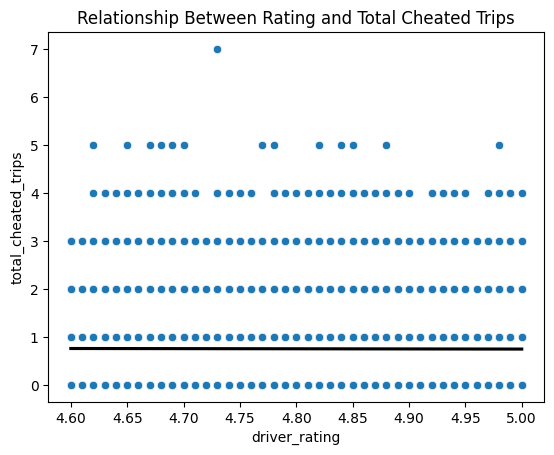

In [67]:
sns.scatterplot(data=cheated_driver_df, x="driver_rating", y="total_cheated_trips")
sns.regplot(data=cheated_driver_df, x='driver_rating',y='total_cheated_trips',color='black',ci=None,scatter=False)
plt.title('Relationship Between Rating and Total Cheated Trips')
plt.show()

In [37]:
query = """
CREATE OR REPLACE TABLE purwadhika-498212.bluebird_capstone.trips_details_idle AS
SELECT
    *,
    DATETIME(booking_time, 'Asia/Jakarta') AS jakarta_booking_time,
    DATETIME(meter_start_time, 'Asia/Jakarta') AS jakarta_meter_start_time,
    DATETIME(dropoff_time, 'Asia/Jakarta') AS jakarta_dropoff_time,
    TIMESTAMP_DIFF(DATETIME(booking_time, 'Asia/Jakarta'), LAG(DATETIME(dropoff_time, 'Asia/Jakarta'), 1) OVER(PARTITION BY driver_id, DATE(DATETIME(booking_time, 'Asia/Jakarta')) ORDER BY booking_time ASC), MINUTE) AS idle_time
FROM
    purwadhika-498212.bluebird_capstone.trips_details
ORDER BY
    driver_id, booking_time
;
"""

job = client.query(query)
job.result()

In [3]:
query = """
SELECT
    driver_pool_location,
    CASE
        WHEN idle_time IS NOT NULL AND idle_time < 0 THEN 'anomaly'
        WHEN idle_time IS NOT NULL THEN 'sufficient'
        ELSE NULL
    END AS idle_time_class,
    COUNT(DISTINCT trip_id) AS total
FROM
    purwadhika-498212.bluebird_capstone.trips_details_idle
GROUP BY ALL
HAVING idle_time_class IS NOT NULL
ORDER BY driver_pool_location, idle_time_class
;
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,driver_pool_location,idle_time_class,total
0,Pool BSD,anomaly,528
1,Pool BSD,sufficient,2433
2,Pool Ciputat,anomaly,527
3,Pool Ciputat,sufficient,2408
4,Pool Halim,anomaly,476
5,Pool Halim,sufficient,2328
6,Pool Kelapa Gading,anomaly,455
7,Pool Kelapa Gading,sufficient,2193
8,Pool Kramat Jati,anomaly,514
9,Pool Kramat Jati,sufficient,2363


In [69]:
query = """
SELECT
    trip_id,
    driver_pool_location,
    idle_time
FROM
    purwadhika-498212.bluebird_capstone.trips_details_idle
WHERE
    idle_time > 0
;
"""

idle_time_pool_df = client.query(query).to_dataframe()
idle_time_pool_df

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,trip_id,driver_pool_location,idle_time
0,TRP000147631,Pool BSD,575
1,TRP000091738,Pool BSD,537
2,TRP000271406,Pool BSD,484
3,TRP000072298,Pool BSD,114
4,TRP000079711,Pool BSD,663
...,...,...,...
16198,TRP000233735,Pool Puri,61
16199,TRP000092076,Pool Puri,891
16200,TRP000065713,Pool Puri,495
16201,TRP000077215,Pool Puri,121


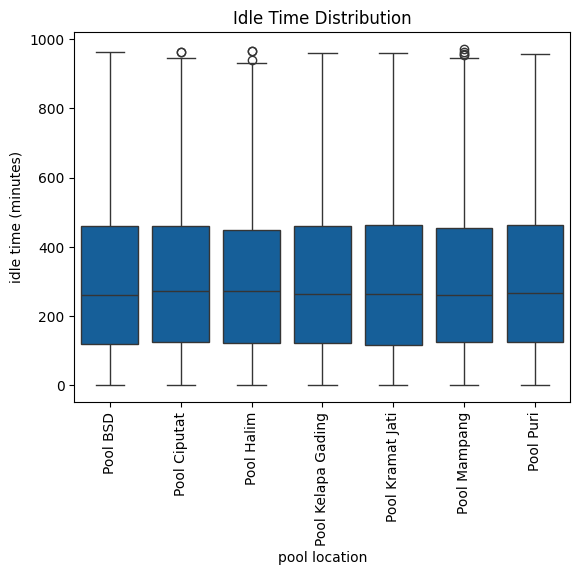

In [74]:
sns.boxplot(y=idle_time_pool_df['idle_time'], x=idle_time_pool_df['driver_pool_location'], color='#0061af')
plt.title('Idle Time Distribution')
plt.xlabel('pool location')
plt.ylabel('idle time (minutes)')
plt.xticks(rotation=90)
plt.show()

In [43]:
query = """
CREATE OR REPLACE TABLE purwadhika-498212.bluebird_capstone.boxplot_idletime AS
WITH raw_data AS (
  SELECT
    driver_pool_location,
    driver_id,
    AVG(idle_time) AS avg_idle_time
  FROM
    `purwadhika-498212.bluebird_capstone.trips_details_idle`
  WHERE idle_time > 0
  GROUP BY ALL
),

iqr AS (
SELECT
  driver_pool_location,
  AVG(avg_idle_time) AS mean_idle_time,
  APPROX_QUANTILES(avg_idle_time, 4)[OFFSET(1)] AS q1,
  APPROX_QUANTILES(avg_idle_time, 4)[OFFSET(2)] AS q2,
  APPROX_QUANTILES(avg_idle_time, 4)[OFFSET(3)] AS q3
FROM
  raw_data
GROUP BY 
  driver_pool_location
ORDER BY 
  q2 DESC
)

SELECT
    *,
    (q1 - (1.5 * (q3-q1))) AS lower_whisker,
    ((1.5 * (q3-q1)) + q3) AS upper_whisker
FROM
    iqr
;
"""

job = client.query(query)
job.result()

In [ ]:
query = """
SELECT
    *
FROM
    purwadhika-498212.bluebird_capstone.boxplot_idletime
;
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,driver_pool_location,mean_idle_time,q1,q2,q3,lower_whisker,upper_whisker
0,Pool Puri,312.258840,170.500000,288.000000,430.333333,-219.250000,820.083333
1,Pool Kelapa Gading,309.056154,168.000000,286.500000,411.500000,-197.250000,776.750000
2,Pool Mampang,308.436303,168.000000,279.250000,418.000000,-207.000000,793.000000
3,Pool BSD,304.554908,160.000000,283.000000,424.000000,-236.000000,820.000000
4,Pool Ciputat,310.991669,170.000000,287.000000,420.000000,-205.000000,795.000000
5,Pool Kramat Jati,301.078618,158.666667,278.500000,412.000000,-221.333333,792.000000
6,Pool Halim,308.721750,176.000000,292.333333,417.500000,-186.250000,779.750000


In [25]:
query = """
SELECT
    ROUND(AVG(q2),2)
FROM
    purwadhika-498212.bluebird_capstone.boxplot_idletime
;
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,f0_
0,284.94


In [45]:
query = """
CREATE OR REPLACE TABLE purwadhika-498212.bluebird_capstone.optimum_driver_hc AS
WITH unique_driver AS (
SELECT driver_pool_location,  DATE(jakarta_booking_time) AS jakarta_date, COUNT(DISTINCT driver_id) AS total_unique_driver
FROM purwadhika-498212.bluebird_capstone.trips_details_idle
GROUP BY ALL
),

unique_driver_perday AS (
SELECT driver_pool_location, AVG(total_unique_driver) AS avg_total_unique_driver
FROM unique_driver
GROUP BY ALL
),

avg_trip_perday AS (
SELECT driver_pool_location, DATE(jakarta_booking_time) AS jakarta_booking_date,  COUNT(DISTINCT trip_id) AS total_trip
FROM purwadhika-498212.bluebird_capstone.trips_details_idle
GROUP BY ALL
),

avg_trip_perday_perpool AS (
SELECT driver_pool_location, AVG(total_trip) AS avg_total_trip
FROM
  avg_trip_perday
GROUP BY ALL
),

driver_avg_trip_perday AS (
SELECT driver_pool_location, driver_id, DATE(jakarta_booking_time) AS jakarta_booking_date,  COUNT(DISTINCT trip_id) AS total_trip
FROM purwadhika-498212.bluebird_capstone.trips_details_idle
GROUP BY ALL
),

driver_avg_trip_perday_perpool AS (
SELECT driver_pool_location, AVG(total_trip) AS avg_total_trip
FROM
  driver_avg_trip_perday
GROUP BY ALL
),

median_travel_time AS (
SELECT
  driver_pool_location,
  APPROX_QUANTILES(TIMESTAMP_DIFF(jakarta_dropoff_time, jakarta_meter_start_time, MINUTE), 2) [OFFSET(1)] AS median_travel_time_minutes
FROM
  purwadhika-498212.bluebird_capstone.trips_details_idle
GROUP BY 
  driver_pool_location
ORDER BY 
  median_travel_time_minutes DESC
),

calculation_estimation AS (
SELECT
  a.driver_pool_location,
  FLOOR(ROUND(a.avg_total_unique_driver, 2)) AS avg_total_driver_perday,
  ROUND(b.avg_total_trip, 2) AS avg_total_trip_perday,
  ROUND(c.avg_total_trip, 2) AS avg_total_trip_perdriver_perday,
  ROUND(d.median_travel_time_minutes, 2) AS median_travel_time_minutes,
  ROUND(((8*60)/d.median_travel_time_minutes),2) AS optimum_trip_perdriver_perday
FROM
  unique_driver_perday AS a
INNER JOIN
  avg_trip_perday_perpool AS b
ON
  a.driver_pool_location = b.driver_pool_location
INNER JOIN
  driver_avg_trip_perday_perpool AS c
ON
  a.driver_pool_location = c.driver_pool_location
INNER JOIN
  median_travel_time AS d
ON
  a.driver_pool_location = d.driver_pool_location
)

SELECT
  *,
  FLOOR(avg_total_trip_perday/optimum_trip_perdriver_perday) AS optimal_active_driver_perday
FROM
  calculation_estimation
;
"""

job = client.query(query)
job.result()

In [75]:
query = """
SELECT
    *
FROM
    purwadhika-498212.bluebird_capstone.optimum_driver_hc
;
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,driver_pool_location,avg_total_driver_perday,avg_total_trip_perday,avg_total_trip_perdriver_perday,median_travel_time_minutes,optimum_trip_perdriver_perday,optimal_active_driver_perday
0,Pool Kelapa Gading,210.0,224.74,1.07,86.0,5.58,40.0
1,Pool Puri,221.0,236.72,1.07,83.0,5.78,40.0
2,Pool Halim,221.0,236.66,1.07,84.0,5.71,41.0
3,Pool Mampang,220.0,235.17,1.07,84.0,5.71,41.0
4,Pool Ciputat,228.0,244.66,1.07,84.0,5.71,42.0
5,Pool Kramat Jati,229.0,245.09,1.07,85.0,5.65,43.0
6,Pool BSD,227.0,243.62,1.07,85.0,5.65,43.0


In [47]:
query = """
CREATE OR REPLACE TABLE purwadhika-498212.bluebird_capstone.trips_details_b2b AS
SELECT
  *,
  CASE
    WHEN payment_method = 'eVoucher Corporate' AND (EXTRACT(DAYOFWEEK FROM jakarta_booking_time) IN (1,7) OR EXTRACT(HOUR FROM jakarta_booking_time) > 22) THEN TRUE
    WHEN payment_method = 'eVoucher Corporate' THEN FALSE
    ELSE NULL
  END AS is_client_fraud,
  CASE
    WHEN payment_method = 'eVoucher Corporate' AND COALESCE(company_id, '') = '' THEN TRUE
    WHEN payment_method = 'eVoucher Corporate' THEN FALSE
    ELSE NULL
  END AS is_missing_company_id
FROM
  purwadhika-498212.bluebird_capstone.trips_details_idle
;
"""

job = client.query(query)
job.result()

In [76]:
query = """
SELECT
    payment_method,
    COUNT(DISTINCT trip_id) AS total
FROM
    purwadhika-498212.bluebird_capstone.trips_details_b2b
GROUP BY
    1
"""

payment_share = client.query(query).to_dataframe()
payment_share

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,payment_method,total
0,Cash,90039
1,MyBluebird App,119764
2,eVoucher Corporate,60279
3,Credit Card,29918


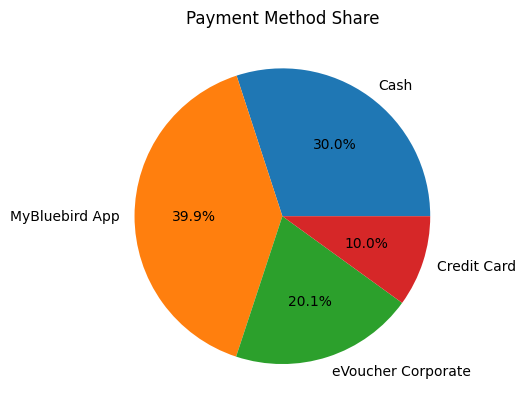

In [79]:
plt.pie(payment_share['total'],labels=payment_share['payment_method'],autopct='%.1f%%')
plt.title('Payment Method Share')
plt.show()

In [84]:
query = """
SELECT
    is_client_fraud,
    COUNT(DISTINCT trip_id) AS total,
    ROUND(COUNT(DISTINCT trip_id) / SUM(COUNT(DISTINCT trip_id)) OVER() * 100, 2) AS percentage
FROM
    purwadhika-498212.bluebird_capstone.trips_details_b2b
WHERE
    is_client_fraud IS NOT NULL
GROUP BY
    1
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,is_client_fraud,total,percentage
0,False,41183,68.32
1,True,19096,31.68


In [86]:
query = """
SELECT
    is_missing_company_id,
    COUNT(DISTINCT trip_id) AS total,
    ROUND(COUNT(DISTINCT trip_id) / SUM(COUNT(DISTINCT trip_id)) OVER() * 100, 2) AS percentage
FROM
    purwadhika-498212.bluebird_capstone.trips_details_b2b
WHERE
    is_missing_company_id IS NOT NULL
GROUP BY
    1
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,is_missing_company_id,total,percentage
0,True,9002,14.93
1,False,51277,85.07


In [4]:
query = """
SELECT
    company_id,
    company_name,
    SUM(total_fare) AS total_trips,
    SUM(CASE WHEN is_client_fraud = TRUE THEN total_fare ELSE 0 END) AS total_cheated_fare,
    ROUND(SUM(CASE WHEN is_client_fraud = TRUE THEN total_fare ELSE 0 END) / SUM(total_fare) * 100, 2) AS percentage
FROM
    purwadhika-498212.bluebird_capstone.trips_details_b2b
WHERE
    is_client_fraud IS NOT NULL
    AND company_id IS NOT NULL
GROUP BY
    ALL
ORDER BY
    4 DESC, 5 DESC
LIMIT 10
"""

client.query(query).to_dataframe()

/Users/dzakwan.muhammad/datascience/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,company_id,company_name,total_trips,total_cheated_fare,percentage
0,CORP-0233,PT. Korporat Sukses 232 Tbk,14939138.9,6639000.0,44.44
1,CORP-0388,PT. Korporat Sukses 387 Tbk,17618388.8,6141500.0,34.86
2,CORP-0043,PT. Korporat Sukses 42 Tbk,16170583.3,6133111.1,37.93
3,CORP-0289,PT. Korporat Sukses 288 Tbk,15626361.1,6085500.0,38.94
4,CORP-0498,PT. Korporat Sukses 497 Tbk,14557000.0,6010500.0,41.29
5,CORP-0273,PT. Korporat Sukses 272 Tbk,14595000.0,5993500.0,41.07
6,CORP-0138,PT. Korporat Sukses 137 Tbk,13994500.0,5903000.0,42.18
7,CORP-0230,PT. Korporat Sukses 229 Tbk,18331500.0,5895500.0,32.16
8,CORP-0123,PT. Korporat Sukses 122 Tbk,12593500.0,5819500.0,46.21
9,CORP-0083,PT. Korporat Sukses 82 Tbk,14606500.0,5796500.0,39.68


# Data Visualization

On Google Looker Studio: https://datastudio.google.com/reporting/164a29a6-e22a-4c4b-860a-fe0bcd3dffee